# Week 5 (continued) — Generator Attribution: *Which* Model Wrote It?

**Goal:** given an essay we already believe is AI-written, predict the **model family** that produced it. This is the "generator attribution" panel planned for the demo (decision 6).

It's a **multi-class** problem (8 families) instead of binary, and it raises its own honesty questions:
- **Imbalance:** Mistral has ~5,200 essays, GPT-4 only 200. Accuracy would be dominated by the big families, so the headline metric is **macro-F1** (F1 per family, then averaged, so every family counts equally).
- **Source vs family:** several families come from more than one *source* (different people generated them, with different prompts and settings). A model could learn a source's prompting quirks instead of the family's style. The honest test **holds out an entire source** and checks whether its essays are still attributed to the right family.
- **Topic leakage:** off-topic AI essays (`06_topic_check`) are concentrated in a few sources, so topic could reveal the family. Report on-topic results too.
- **Open set:** a real essay may come from a model none of these 8 families covers. The classifier will still force it into one of them. Flagged at the end.

In [1]:
import os
import sys
sys.path.append('..')
os.environ['PYTORCH_CUDA_ALLOC_CONF'] = 'expandable_segments:True'

import gc
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
import torch
import torch.nn.functional as F
import transformers
from transformers import AutoTokenizer, AutoModelForSequenceClassification, get_linear_schedule_with_warmup
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import f1_score, accuracy_score, confusion_matrix

from src.data import load_splits

transformers.logging.set_verbosity_error()
SEED = 42
torch.manual_seed(SEED)
pd.set_option('display.width', 200)
device = torch.device('cuda')
BLUES = LinearSegmentedColormap.from_list('blues', ['#ffffff', '#cde2fb', '#86b6ef', '#3987e5', '#256abf', '#184f95', '#0d366b'])
plt.rcParams.update({'figure.dpi': 110, 'axes.titleweight': 'bold'})

## Step 1 — From sources to families

The 15 AI sources map onto 8 model families. `radek_500` is assumed to be GPT-3.5 (ChatGPT), from its name and the DAIGT-V2 dataset notes; if that turns out wrong, only this mapping changes. The 3 AI-labelled rows of `train_essays` have no known generator, so they're dropped.

In [2]:
FAMILY = {
    'chat_gpt_moth': 'GPT-3.5', 'radek_500': 'GPT-3.5',
    'radekgpt4': 'GPT-4',
    'darragh_claude_v6': 'Claude', 'darragh_claude_v7': 'Claude',
    'kingki19_palm': 'PaLM', 'palm-text-bison1': 'PaLM',
    'cohere-command': 'Cohere',
    'llama2_chat': 'Llama 2', 'NousResearch/Llama-2-7b-chat-hf': 'Llama 2', 'llama_70b_v1': 'Llama 2',
    'mistral7binstruct_v1': 'Mistral', 'mistral7binstruct_v2': 'Mistral', 'mistralai/Mistral-7B-Instruct-v0.1': 'Mistral',
    'falcon_180b_v1': 'Falcon',
}
data = load_splits()
ai = data[(data['label'] == 1) & data['source'].isin(FAMILY)].drop(columns='split').copy()
ai['family'] = ai['source'].map(FAMILY)
FAMILIES = sorted(ai['family'].unique())
fam_id = {f: i for i, f in enumerate(FAMILIES)}
ai['y'] = ai['family'].map(fam_id)

gpt2 = pd.read_csv('../results/10_gpt2_features.csv', index_col='row_id')
ai = ai.join(gpt2)

summary = ai.groupby('family').agg(essays=('y', 'size'), sources=('source', 'nunique'),
                                   on_topic_pct=('on_topic', 'mean'), median_words=('n_words', 'median'))
summary['on_topic_pct'] = (summary['on_topic_pct'] * 100).round(1)
print(f"{len(ai):,} AI essays in {len(FAMILIES)} families")
summary.sort_values('essays', ascending=False)

17,490 AI essays in 8 families


,essays,sources,on_topic_pct,median_words
family,,,,
Mistral,5239,3,30.2,358.0
Llama 2,3992,3,40.4,335.0
GPT-3.5,2921,2,31.6,218.0
Claude,2000,2,93.5,307.5
PaLM,1733,2,99.9,385.0
Falcon,1055,1,45.2,295.0
Cohere,350,1,99.1,308.5
GPT-4,200,1,100.0,449.0


## Step 2 — Two evaluation designs

**(A) Random split, grouped and stratified.** 80/10/10 of AI essays with `StratifiedGroupKFold` (groups = `dup_cluster`, stratify = family), exactly the recipe of `03_split`. Every *source* appears in train and test, so this measures "recognise a family whose sources you've seen".

**(B) Leave-one-source-out.** For each of the 4 families built from several sources, hold out its **smallest** source completely:

| Family | Held-out source |
|---|---|
| GPT-3.5 | `radek_500` |
| PaLM | `palm-text-bison1` |
| Llama 2 | `NousResearch/Llama-2-7b-chat-hf` |
| Mistral | `mistralai/Mistral-7B-Instruct-v0.1` |

Train on everything else (with design A's val essays from the remaining sources for tuning), then ask: *are the unseen sources' essays assigned to their correct family?* If the model only learned each source's quirks, this collapses.

In [3]:
sgkf = StratifiedGroupKFold(n_splits=10, shuffle=True, random_state=SEED)
fold = pd.Series(-1, index=ai.index)
for k, (_, idx) in enumerate(sgkf.split(ai, ai['y'], groups=ai['dup_cluster'])):
    fold.iloc[idx] = k
ai['attr_split'] = np.select([fold == 0, fold == 1], ['test', 'val'], default='train')
assert (ai.groupby('dup_cluster')['attr_split'].nunique() == 1).all()

HELDOUT_SOURCES = ['radek_500', 'palm-text-bison1', 'NousResearch/Llama-2-7b-chat-hf', 'mistralai/Mistral-7B-Instruct-v0.1']
held = ai['source'].isin(HELDOUT_SOURCES)

print(pd.crosstab(ai['family'], ai['attr_split'])[['train', 'val', 'test']])
print(f"\nleave-one-source-out: {held.sum():,} essays held out from {len(HELDOUT_SOURCES)} sources")

attr_split  train  val  test
family                      
Claude       1600  200   200
Cohere        280   35    35
Falcon        843  106   106
GPT-3.5      2337  292   292
GPT-4         160   20    20
Llama 2      3194  399   399
Mistral      4191  524   524
PaLM         1385  174   174

leave-one-source-out: 1,648 essays held out from 4 sources


## Step 3 — Reference: GPT-2 features alone

`10_zero_shot` found that families differ a lot in perplexity (PaLM ≈ 5.5, Claude ≈ 26). How far do those **3 numbers** get on their own? Multinomial logistic regression, `class_weight='balanced'` (each family weighted inversely to its size, so the classifier can't ignore GPT-4).

In [4]:
FEATS = ['log_ppl', 'burstiness', 'log_rank']
tr, va, te = (ai[ai['attr_split'] == s] for s in ['train', 'val', 'test'])

def report(y_true, y_pred):
    return {'accuracy': accuracy_score(y_true, y_pred), 'macro_F1': f1_score(y_true, y_pred, average='macro')}

gpt2_lr = make_pipeline(StandardScaler(), LogisticRegression(max_iter=2000, class_weight='balanced')).fit(tr[FEATS], tr['y'])
results = {'GPT-2 features (3 numbers)': report(te['y'], gpt2_lr.predict(te[FEATS]))}
print(results)

{'GPT-2 features (3 numbers)': {'accuracy': 0.43885714285714283, 'macro_F1': 0.40625482963135323}}


## Step 4 — TF-IDF + Linear SVM (multi-class)

Same features as the Week 1 detector (word 1–2-grams, fit on attribution-train only). `LinearSVC` handles multiple classes **one-vs-rest**: one binary SVM per family ("this family vs all others"), and the family with the highest score wins. `C` is tuned on val by macro-F1.

In [5]:
t0 = time.time()
vec = TfidfVectorizer(ngram_range=(1, 2), min_df=3, max_features=200_000, sublinear_tf=True).fit(tr['text'])
X = {s: vec.transform(d['text']) for s, d in [('train', tr), ('val', va), ('test', te)]}
best = max(((C, f1_score(va['y'], LinearSVC(C=C, class_weight='balanced').fit(X['train'], tr['y']).predict(X['val']), average='macro'))
            for C in [0.1, 0.3, 1, 3]), key=lambda t: t[1])
print(f"best C = {best[0]} (val macro-F1 {best[1]:.4f})")
svm = LinearSVC(C=best[0], class_weight='balanced').fit(X['train'], tr['y'])
pred_svm = svm.predict(X['test'])
results['TF-IDF + LinearSVM'] = report(te['y'], pred_svm)
print(results['TF-IDF + LinearSVM'], f"({time.time() - t0:.0f}s)")

best C = 3 (val macro-F1 0.9764)


{'accuracy': 0.9817142857142858, 'macro_F1': 0.9759987100798487} (68s)


## Step 5 — Fine-tuned DistilRoBERTa, 8-way

The `08_bert` recipe with one change: the classification head has **8 outputs**, one logit per family. **Softmax** turns them into probabilities that sum to 1, and the loss is **cross-entropy**. To mirror `class_weight='balanced'`, each family's loss is weighted inversely to its training count.

We start from the *pretrained* `distilroberta-base`, not the human-vs-AI detector from `08`. The detector learned "AI vs human", which isn't obviously useful for telling AI families apart. (Starting from it is a possible later experiment.)

In [6]:
tokenizer = AutoTokenizer.from_pretrained('distilroberta-base')
ai['ids'] = tokenizer(ai['text'].tolist(), truncation=True, max_length=512)['input_ids']
tr, va, te = (ai[ai['attr_split'] == s] for s in ['train', 'val', 'test'])   # re-slice so they carry the new `ids` column
PAD_ID = tokenizer.pad_token_id

def batches(df, batch_size=16, shuffle=False, seed=0):
    ids, labels = df['ids'].tolist(), df['y'].to_numpy()
    order = np.argsort([len(x) for x in ids], kind='stable')
    chunks = [order[i:i + batch_size] for i in range(0, len(order), batch_size)]
    if shuffle:
        np.random.default_rng(seed).shuffle(chunks)
    for chunk in chunks:
        width = max(len(ids[i]) for i in chunk)
        x = torch.full((len(chunk), width), PAD_ID, dtype=torch.long)
        for r, i in enumerate(chunk):
            x[r, :len(ids[i])] = torch.tensor(ids[i])
        yield x, (x != PAD_ID).long(), torch.tensor(labels[chunk]), chunk

@torch.no_grad()
def predict_proba(model, df, batch_size=64):
    model.eval()
    out = np.empty((len(df), len(FAMILIES)), dtype=np.float32)
    with torch.autocast('cuda', dtype=torch.float16):
        for x, mask, _, chunk in batches(df, batch_size):
            out[chunk] = F.softmax(model(input_ids=x.to(device), attention_mask=mask.to(device)).logits.float(), -1).cpu().numpy()
    return out

def train_attr(train_df, val_df, epochs=2, lr=3e-5, batch_size=16, seed=SEED):
    torch.manual_seed(seed)
    model = AutoModelForSequenceClassification.from_pretrained('distilroberta-base', num_labels=len(FAMILIES)).to(device)
    counts = np.bincount(train_df['y'], minlength=len(FAMILIES))
    class_w = torch.tensor(len(train_df) / (len(FAMILIES) * np.maximum(counts, 1)), dtype=torch.float32, device=device)
    opt = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=0.01)
    steps = epochs * int(np.ceil(len(train_df) / batch_size))
    sched = get_linear_schedule_with_warmup(opt, int(0.06 * steps), steps)
    scaler = torch.amp.GradScaler()
    best_f1, best_state = -1, None
    for epoch in range(1, epochs + 1):
        model.train(); t0 = time.time(); losses = []
        for x, mask, y, _ in batches(train_df, batch_size, shuffle=True, seed=seed + epoch):
            with torch.autocast('cuda', dtype=torch.float16):
                logits = model(input_ids=x.to(device), attention_mask=mask.to(device)).logits
            loss = F.cross_entropy(logits.float(), y.to(device), weight=class_w)
            opt.zero_grad(); scaler.scale(loss).backward(); scaler.unscale_(opt)
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            scaler.step(opt); scaler.update(); sched.step(); losses.append(loss.item())
        val_f1 = f1_score(val_df['y'], predict_proba(model, val_df).argmax(1), average='macro')
        print(f"  epoch {epoch}: loss {np.mean(losses):.4f} | val macro-F1 {val_f1:.4f} | {(time.time() - t0) / 60:.1f} min")
        if val_f1 > best_f1:
            best_f1, best_state = val_f1, {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
    model.load_state_dict(best_state)
    return model

print("Design A: random grouped split")
roberta = train_attr(tr, va)
proba_rob = predict_proba(roberta, te)
pred_rob = proba_rob.argmax(1)
results['DistilRoBERTa (fine-tuned)'] = report(te['y'], pred_rob)
pd.DataFrame(results).T.round(4)

Design A: random grouped split


Loading weights:   0%|          | 0/101 [00:00<?, ?it/s]

  epoch 1: loss 0.6712 | val macro-F1 0.8837 | 5.4 min


  epoch 2: loss 0.1277 | val macro-F1 0.9344 | 5.4 min


,accuracy,macro_F1
GPT-2 features (3 numbers),0.4389,0.4063
TF-IDF + LinearSVM,0.9817,0.9760
DistilRoBERTa (fine-tuned),0.9651,0.9428


## Step 6 — Per family, and on-topic only

Overall numbers hide which families get confused. **Recall per family** (share of a family's test essays attributed correctly), for all test essays and for on-topic ones only. If on-topic recall drops a lot, topic was giving the family away.

In [7]:
def per_family(df, pred):
    out = pd.DataFrame({'family': df['family'].to_numpy(), 'ok': pred == df['y'].to_numpy(), 'on_topic': df['on_topic'].to_numpy()})
    return pd.DataFrame({'test essays': out.groupby('family').size(),
                         'recall, all': out.groupby('family')['ok'].mean(),
                         'on-topic essays': out[out['on_topic']].groupby('family').size(),
                         'recall, on-topic': out[out['on_topic']].groupby('family')['ok'].mean()})

tables = {'TF-IDF + LinearSVM': per_family(te, pred_svm), 'DistilRoBERTa': per_family(te, pred_rob)}
on = te['on_topic'].to_numpy()
for name, pred in [('TF-IDF + LinearSVM', pred_svm), ('DistilRoBERTa', pred_rob)]:
    print(f"{name}: macro-F1 all {f1_score(te['y'], pred, average='macro'):.4f} | on-topic {f1_score(te['y'][on], pred[on], average='macro'):.4f}")
pd.concat(tables, axis=1).round(3)

TF-IDF + LinearSVM: macro-F1 all 0.9760 | on-topic 0.9810
DistilRoBERTa: macro-F1 all 0.9428 | on-topic 0.9342


TF-IDF + LinearSVM                                              DistilRoBERTa                                             
               test essays recall, all on-topic essays recall, on-topic   test essays recall, all on-topic essays recall, on-topic
family                                                                                                                            
Claude                 200       1.000             195            1.000           200       1.000             195            1.000
Cohere                  35       0.886              34            0.912            35       0.771              34            0.765
Falcon                 106       0.943              50            0.920           106       0.953              50            0.920
GPT-3.5                292       0.983              89            1.000           292       0.955              89            0.944
GPT-4                   20       1.000              20            1.000            20       0.900              20            0.900
Llama 2                399       0.967             167            0.994           399       0.952             167            0.964
Mistral                524       0.992             147            0.993           524       0.983             147            0.952
PaLM                   174       1.000             174            1.000           174       0.971             174            0.971

**Confusion matrix** for DistilRoBERTa: row = true family, column = predicted family, each row normalised to 100%. The diagonal is correct attribution; off-diagonal cells show *which* families get mistaken for each other.

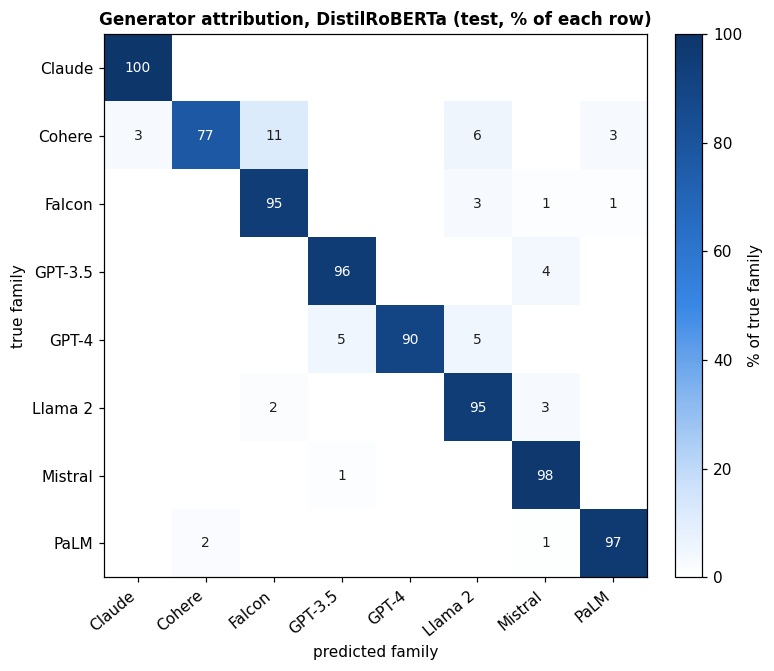

In [8]:
cm = confusion_matrix(te['y'], pred_rob, labels=range(len(FAMILIES)), normalize='true') * 100
fig, ax = plt.subplots(figsize=(7.5, 6.2))
im = ax.imshow(cm, cmap=BLUES, vmin=0, vmax=100)
ax.set_xticks(range(len(FAMILIES)), FAMILIES, rotation=40, ha='right'); ax.set_yticks(range(len(FAMILIES)), FAMILIES)
for i in range(len(FAMILIES)):
    for j in range(len(FAMILIES)):
        if cm[i, j] >= 0.5:
            ax.text(j, i, f"{cm[i, j]:.0f}", ha='center', va='center', fontsize=9, color='white' if cm[i, j] > 55 else '#1f1f1d')
ax.set_xlabel('predicted family'); ax.set_ylabel('true family')
ax.set_title('Generator attribution, DistilRoBERTa (test, % of each row)', fontsize=11)
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label='% of true family')
fig.tight_layout()
fig.savefig('../images/11_attribution_confusion.png', dpi=150, bbox_inches='tight')
plt.show()

## Step 7 — Leave-one-source-out (design B)

Retrain both models **without the 4 held-out sources**, then attribute those sources' essays. The question is simply: *what share of each unseen source lands in its true family?* And which wrong family does it go to instead?

In [9]:
tr_b, va_b = tr[~tr['source'].isin(HELDOUT_SOURCES)], va[~va['source'].isin(HELDOUT_SOURCES)]
unseen = ai[held]

vec_b = TfidfVectorizer(ngram_range=(1, 2), min_df=3, max_features=200_000, sublinear_tf=True).fit(tr_b['text'])
svm_b = LinearSVC(C=best[0], class_weight='balanced').fit(vec_b.transform(tr_b['text']), tr_b['y'])
pred_svm_b = svm_b.predict(vec_b.transform(unseen['text']))

print("Design B: DistilRoBERTa without the held-out sources")
del roberta; gc.collect(); torch.cuda.empty_cache()
roberta_b = train_attr(tr_b, va_b)
proba_rob_b = predict_proba(roberta_b, unseen)
pred_rob_b = proba_rob_b.argmax(1)

rows = []
for src in HELDOUT_SOURCES:
    m = (unseen['source'] == src).to_numpy()
    for name, pred in [('TF-IDF + LinearSVM', pred_svm_b), ('DistilRoBERTa', pred_rob_b)]:
        p = pred[m]
        wrong = pd.Series([FAMILIES[i] for i in p[p != fam_id[FAMILY[src]]]]).value_counts()
        rows.append({'held-out source': src, 'true family': FAMILY[src], 'model': name, 'essays': int(m.sum()),
                     '% correct family': (p == fam_id[FAMILY[src]]).mean() * 100,
                     'most common wrong family': f"{wrong.index[0]} ({wrong.iloc[0] / m.sum() * 100:.0f}%)" if len(wrong) else '-'})
loso = pd.DataFrame(rows).set_index(['held-out source', 'model'])
loso.round(1)

Design B: DistilRoBERTa without the held-out sources


Loading weights:   0%|          | 0/101 [00:00<?, ?it/s]

  epoch 1: loss 0.6147 | val macro-F1 0.9293 | 4.9 min


  epoch 2: loss 0.1073 | val macro-F1 0.9618 | 4.9 min


true family  essays  % correct family most common wrong family
held-out source                    model                                                                            
radek_500                          TF-IDF + LinearSVM     GPT-3.5     500               0.0              GPT-4 (99%)
                                   DistilRoBERTa          GPT-3.5     500               0.0               PaLM (44%)
palm-text-bison1                   TF-IDF + LinearSVM        PaLM     349              28.1             Cohere (43%)
                                   DistilRoBERTa             PaLM     349              24.6            Llama 2 (40%)
NousResearch/Llama-2-7b-chat-hf    TF-IDF + LinearSVM     Llama 2     400              17.5              GPT-4 (73%)
                                   DistilRoBERTa          Llama 2     400               0.2             Cohere (63%)
mistralai/Mistral-7B-Instruct-v0.1 TF-IDF + LinearSVM     Mistral     399               1.8              GPT-4 (52%)
                                   DistilRoBERTa          Mistral     399               0.0               PaLM (79%)

## Step 8 — Confidence, and the open-set problem

A softmax always sums to 1, so the model *always* names a family, even for a model it has never seen. One partial safeguard: the **top probability**. If the model is unsure, the demo should say "uncertain" rather than name a family. Compare the top probability on design A's test essays (sources seen in training) with design B's unseen sources:

In [10]:
conf_seen = proba_rob.max(1)
conf_unseen = proba_rob_b.max(1)
correct_unseen = pred_rob_b == unseen['y'].to_numpy()
print(f"median top probability: seen sources {np.median(conf_seen):.3f} | unseen sources {np.median(conf_unseen):.3f}")
for label, m in [('below 0.9', conf_unseen < 0.9), ('at least 0.9', conf_unseen >= 0.9)]:
    acc = f"{correct_unseen[m].mean() * 100:.0f}% correct" if m.any() else "none"
    print(f"unseen sources, top probability {label:12s}: {m.mean() * 100:5.1f}% of essays, {acc}")

median top probability: seen sources 0.999 | unseen sources 0.895
unseen sources, top probability below 0.9   :  51.2% of essays, 1% correct
unseen sources, top probability at least 0.9:  48.8% of essays, 10% correct


## Step 9 — Save

In [11]:
pd.DataFrame(results).T.round(4).to_csv('../results/11_attribution.csv')
loso.round(2).to_csv('../results/11_attribution_loso.csv')
roberta_b = None; gc.collect(); torch.cuda.empty_cache()
print(pd.DataFrame(results).T.round(4))

                            accuracy  macro_F1
GPT-2 features (3 numbers)    0.4389    0.4063
TF-IDF + LinearSVM            0.9817    0.9760
DistilRoBERTa (fine-tuned)    0.9651    0.9428


## Key takeaways

- **On a random split, attribution looks excellent.** TF-IDF + LinearSVM macro-F1 **0.976** (on-topic 0.981), fine-tuned DistilRoBERTa 0.943. Every family is above 77% recall; Claude and PaLM are near 100%. Topic is *not* what drives it (on-topic scores are just as high). GPT-2's 3 features alone get only 0.41, so perplexity separates families only coarsely.
- **But it doesn't generalise to a new source of the same family.** Leave-one-source-out, share of essays given the right family:

  | held-out source | true family | TF-IDF | DistilRoBERTa |
  |---|---|---|---|
  | `radek_500` | GPT-3.5* | 0% (99% → GPT-4) | 0% |
  | `palm-text-bison1` | PaLM | 28% | 25% |
  | `NousResearch/Llama-2-7b-chat-hf` | Llama 2 | 18% | 0.2% |
  | `mistralai/Mistral-7B-Instruct-v0.1` | Mistral | 2% | 0% |

  That's at or below the 12.5% of random guessing among 8 families. **The models recognise the *source*** (who generated the essays, with which prompts, instructions and settings), **not the model family.** Within DAIGT-V2 each family's style is entangled with its sources' prompting pipeline, so "which family" can't be separated from "which pipeline".
- **\*Caveat on `radek_500`:** its family (GPT-3.5) is assumed from the name. TF-IDF puts 99% of it in GPT-4, and the GPT-4 essays (`radekgpt4`) come from the same author. That's either the same-author effect again, or the assumption is wrong. The other three held-out sources fail regardless, so the conclusion doesn't depend on it.
- **Confidence doesn't rescue it.** Median top probability is 0.999 on seen sources vs 0.895 on unseen ones, so it drops, but among unseen-source essays with top probability ≥ 0.9, only **10%** get the right family. The model is confidently wrong, so a confidence cut-off can't make attribution safe.
- **Consequence for the demo (decision 6):** a "this was written by GPT-4" panel would be misleading for any essay not generated the way DAIGT-V2's contributors did it. Options: drop the panel, relabel it as "most similar to these training sources" with a clear caveat, or keep it only as a demonstration of *why* attribution is unreliable. This needs a decision.
